In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Chargement du dataset (ajuste le nom exact de ton fichier si besoin)
df = pd.read_csv("../data/raw/heart.csv")

# Affichage des 5 premières lignes pour vérifier que tout est bien chargé
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


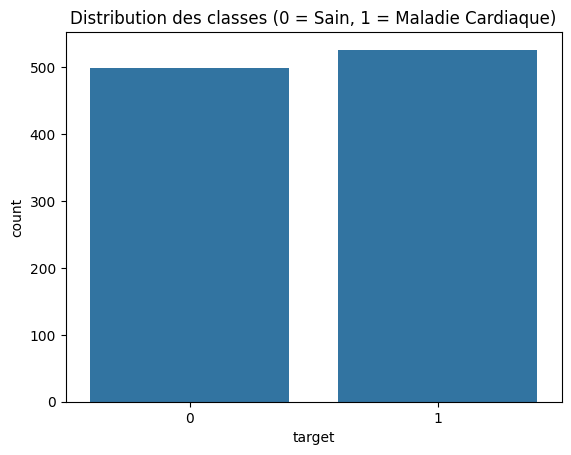

In [3]:
sns.countplot(x='target', data=df)
plt.title("Distribution des classes (0 = Sain, 1 = Maladie Cardiaque)")
plt.show()


In [4]:
# Identifier explicitement tes variables catégorielles (à adapter selon ton fichier exact)
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Application du One-Hot Encoding (transformation en variables binaires 0 ou 1)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Affichage de la nouvelle forme du dataset
print(f"Ancienne forme : {df.shape}")
print(f"Nouvelle forme après encodage : {df_encoded.shape}")
df_encoded.head()

Ancienne forme : (1025, 14)
Nouvelle forme après encodage : (1025, 23)


,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,125,212,168,1.0,0,True,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,140,203,155,3.1,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,145,174,125,2.6,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,148,203,161,0.0,0,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,138,294,106,1.9,0,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [5]:
# 1. Séparer les fonctionnalités (X) de la cible (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# 2. Première séparation : 70% Train et 30% temporaire (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# 3. Deuxième séparation : On divise les 30% temporaires en deux parties égales (15% Val, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Taille de l'entraînement : {X_train.shape[0]} lignes")
print(f"Taille de la validation : {X_val.shape[0]} lignes")
print(f"Taille du test : {X_test.shape[0]} lignes")

Taille de l'entraînement : 717 lignes
Taille de la validation : 154 lignes
Taille du test : 154 lignes


In [6]:
scaler = StandardScaler()

# On ajuste le scaler UNIQUEMENT sur le Train set pour éviter la fuite de données (Data Leakage)
X_train_scaled = scaler.fit_transform(X_train)

# On applique la même transformation sur la Validation et le Test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Sauvegarde des données prêtes pour l'étape suivante dans ton dossier 'processed'
np.save("../data/processed/X_train.npy", X_train_scaled)
np.save("../data/processed/X_val.npy", X_val_scaled)
np.save("../data/processed/X_test.npy", X_test_scaled)

# Sauvegarde des étiquettes (labels)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_val.to_csv("../data/processed/y_val.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

print("🎉 Étape de Data Engineering terminée et sauvegardée avec succès !")

🎉 Étape de Data Engineering terminée et sauvegardée avec succès !


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np         # 👈 Indispensable pour np.load
import pandas as pd        # 👈 Indispensable pour pd.read_csv

print("--- Chargement et conversion des données ---")

# 1. Chargement des données normalisées depuis le dossier processed
X_train_np = np.load("../data/processed/X_train.npy")
X_val_np = np.load("../data/processed/X_val.npy")
X_test_np = np.load("../data/processed/X_test.npy")

y_train_np = pd.read_csv("../data/processed/y_train.csv").values.astype(np.float32)
y_val_np = pd.read_csv("../data/processed/y_val.csv").values.astype(np.float32)
y_test_np = pd.read_csv("../data/processed/y_test.csv").values.astype(np.float32)

# 2. Conversion en Tenseurs PyTorch
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_np, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32)

# 3. Création des structures Dataset et DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Définition de la dimension d'entrée
input_dim = X_train_tensor.shape[1]
print(f"✅ Succès ! Nombre de caractéristiques en entrée du MLP : {input_dim}")

--- Chargement et conversion des données ---
✅ Succès ! Nombre de caractéristiques en entrée du MLP : 22


In [3]:
import torch
import torch.nn as nn

print("--- 1. Définition et création du modèle ---")

# Définition de l'architecture (Classe requise par l'EMSI)
class HeartDiseaseMLP(nn.Module):
    def __init__(self, input_size):
        super(HeartDiseaseMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# Instanciation (Vérifie bien que la cellule du DataLoader avec 'input_dim' a été exécutée avant)
model_custom = HeartDiseaseMLP(input_size=input_dim)
print("Modèle instancié avec succès.")

print("\n--- 2. Configuration du matériel (Device) ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Le modèle sera entraîné sur : {device}")

# Envoi du modèle sur le processeur choisi (CPU ou GPU)
model_custom = model_custom.to(device)

print("\n--- 3. Définition de la Perte et de l'Optimiseur ---")
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_custom.parameters(), lr=0.001)

print("✅ Tout est configuré et prêt en mémoire !")

--- 1. Définition et création du modèle ---
Modèle instancié avec succès.

--- 2. Configuration du matériel (Device) ---
Le modèle sera entraîné sur : cpu

--- 3. Définition de la Perte et de l'Optimiseur ---
✅ Tout est configuré et prêt en mémoire !


In [4]:
import copy

epochs = 50
train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_weights = None

print("🚀 Début de l'entraînement...\n")

for epoch in range(epochs):
    # --- PHASE D'ENTRAÎNEMENT ---
    model_custom.train() # Mode entraînement activé
    running_train_loss = 0.0
    
    for inputs, labels in train_loader:
        # Envoi des mini-lots sur le GPU ou CPU
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Réinitialisation des gradients accumulés
        optimizer.zero_grad()
        
        # Propagation avant (Forward pass)
        outputs = model_custom(inputs)
        loss = criterion(outputs, labels)
        
        # Rétropropagation (Backward pass pour calculer les gradients)
        loss.backward()
        
        # Mise à jour des poids par l'optimiseur
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # --- PHASE DE VALIDATION ---
    model_custom.eval() # Mode évaluation activé (bloque les mises à jour)
    running_val_loss = 0.0
    
    with torch.no_grad(): # Pas besoin de calculer les gradients, gain de mémoire
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_custom(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    # --- SAUVEGARDE DES MEILLEURS POIDS ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model_custom.state_dict())
        
    # Affichage des logs toutes les 5 époques pour suivre la progression
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Époque {epoch+1:2d}/{epochs} -> Loss Train: {epoch_train_loss:.4f} | Loss Val: {epoch_val_loss:.4f}")

# Recharger les poids optimaux trouvés avant la fin des époques
if best_model_weights is not None:
    model_custom.load_state_dict(best_model_weights)

# Sauvegarde physique exigée dans ton dossier 'models/'
torch.save(model_custom.state_dict(), "../models/best_mlp_model.pth")
print("\n💾 Entraînement terminé ! Le meilleur modèle a été sauvegardé sous 'models/best_mlp_model.pth'.")

🚀 Début de l'entraînement...

Époque  1/50 -> Loss Train: 0.6438 | Loss Val: 0.5757
Époque  5/50 -> Loss Train: 0.2904 | Loss Val: 0.2708
Époque 10/50 -> Loss Train: 0.1916 | Loss Val: 0.1956
Époque 15/50 -> Loss Train: 0.1357 | Loss Val: 0.1446
Époque 20/50 -> Loss Train: 0.0934 | Loss Val: 0.1142
Époque 25/50 -> Loss Train: 0.0617 | Loss Val: 0.0892
Époque 30/50 -> Loss Train: 0.0423 | Loss Val: 0.0654
Époque 35/50 -> Loss Train: 0.0273 | Loss Val: 0.0493
Époque 40/50 -> Loss Train: 0.0190 | Loss Val: 0.0331
Époque 45/50 -> Loss Train: 0.0137 | Loss Val: 0.0273
Époque 50/50 -> Loss Train: 0.0103 | Loss Val: 0.0191

💾 Entraînement terminé ! Le meilleur modèle a été sauvegardé sous 'models/best_mlp_model.pth'.


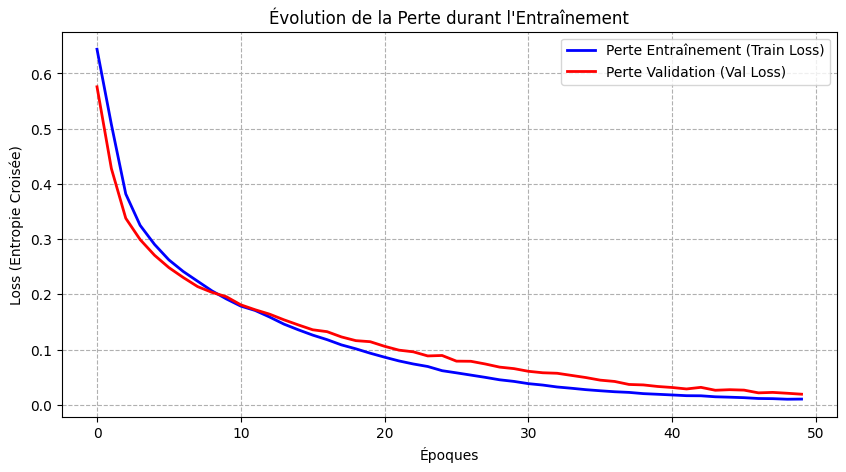

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Perte Entraînement (Train Loss)', color='blue', lw=2)
plt.plot(val_losses, label='Perte Validation (Val Loss)', color='red', lw=2)
plt.xlabel('Époques')
plt.ylabel('Loss (Entropie Croisée)')
plt.title("Évolution de la Perte durant l'Entraînement")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

--- 📊 PERFORMANCES DU MODÈLE SUR L'ENSEMBLE DE TEST ---
Accuracy  (Précision Globale) : 0.9481
Precision (Pertinence)        : 0.9383
Recall    (Rappel / Sensibilité): 0.9620  <-- Très important !
F1-Score  (Mesure Combinée)    : 0.9500



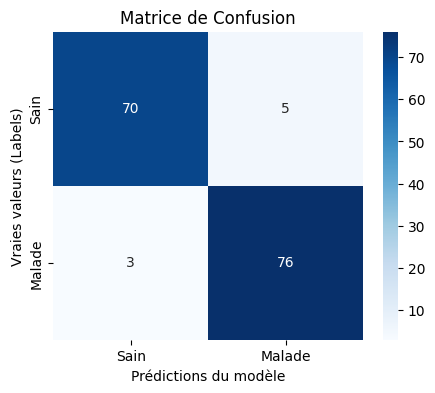

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model_custom.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_custom(inputs)
        
        # Les sorties de la sigmoïde sont des probabilités entre 0 et 1.
        # Si p >= 0.5, la classe prédite est 1 (Malade), sinon 0 (Sain).
        preds = (outputs >= 0.5).float()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calcul des indicateurs de performance
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("--- 📊 PERFORMANCES DU MODÈLE SUR L'ENSEMBLE DE TEST ---")
print(f"Accuracy  (Précision Globale) : {accuracy:.4f}")
print(f"Precision (Pertinence)        : {precision:.4f}")
print(f"Recall    (Rappel / Sensibilité): {recall:.4f}  <-- Très important !")
print(f"F1-Score  (Mesure Combinée)    : {f1:.4f}\n")

# Affichage visuel de la matrice de confusion
import seaborn as sns
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Sain', 'Malade'], yticklabels=['Sain', 'Malade'])
plt.xlabel('Prédictions du modèle')
plt.ylabel('Vraies valeurs (Labels)')
plt.title('Matrice de Confusion')
plt.show()